In [3]:
%load_ext autoreload
%autoreload 2

In [43]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from rna_vel_pred import datasets, utils

In [ ]:
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [8]:
alt_ids = {
    ('3xaym781', 'Model'): {},
}

In [9]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('3xaym781', 'Model'): {'cfg': Conf(root_dir='/home/reepoi/GitHub/velocityPrediction-new',
                                     out_dir='/home/reepoi/out/rna_vel_pred-new',
                                     data_subdir='/home/reepoi/out/rna_vel_pred-new/data_redesign',
                                     run_subdir='runs',
                                     prediction_filename='prediction.parquet',
                                     device='cuda',
                                     alt_id='3xaym781',
                                     rng_seed=2376999025,
                                     fit=False,
                                     predict=True,
                                     id=4,
                                     datasets=[SimpleMotif(time_step_count_sparsify=10,
                                                           neighbor_count=10,
                                                           frac_train=0.7,
                                          

In [46]:
for v in cfgs.values():
    v['pred'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)
    v['pred']['cosine_similarity'] = 0.5 * np.square(
        v['pred'][['v1_pred', 'v2_pred']].to_numpy()
        - v['pred'][['v1', 'v2']].to_numpy()
    ).sum(1)

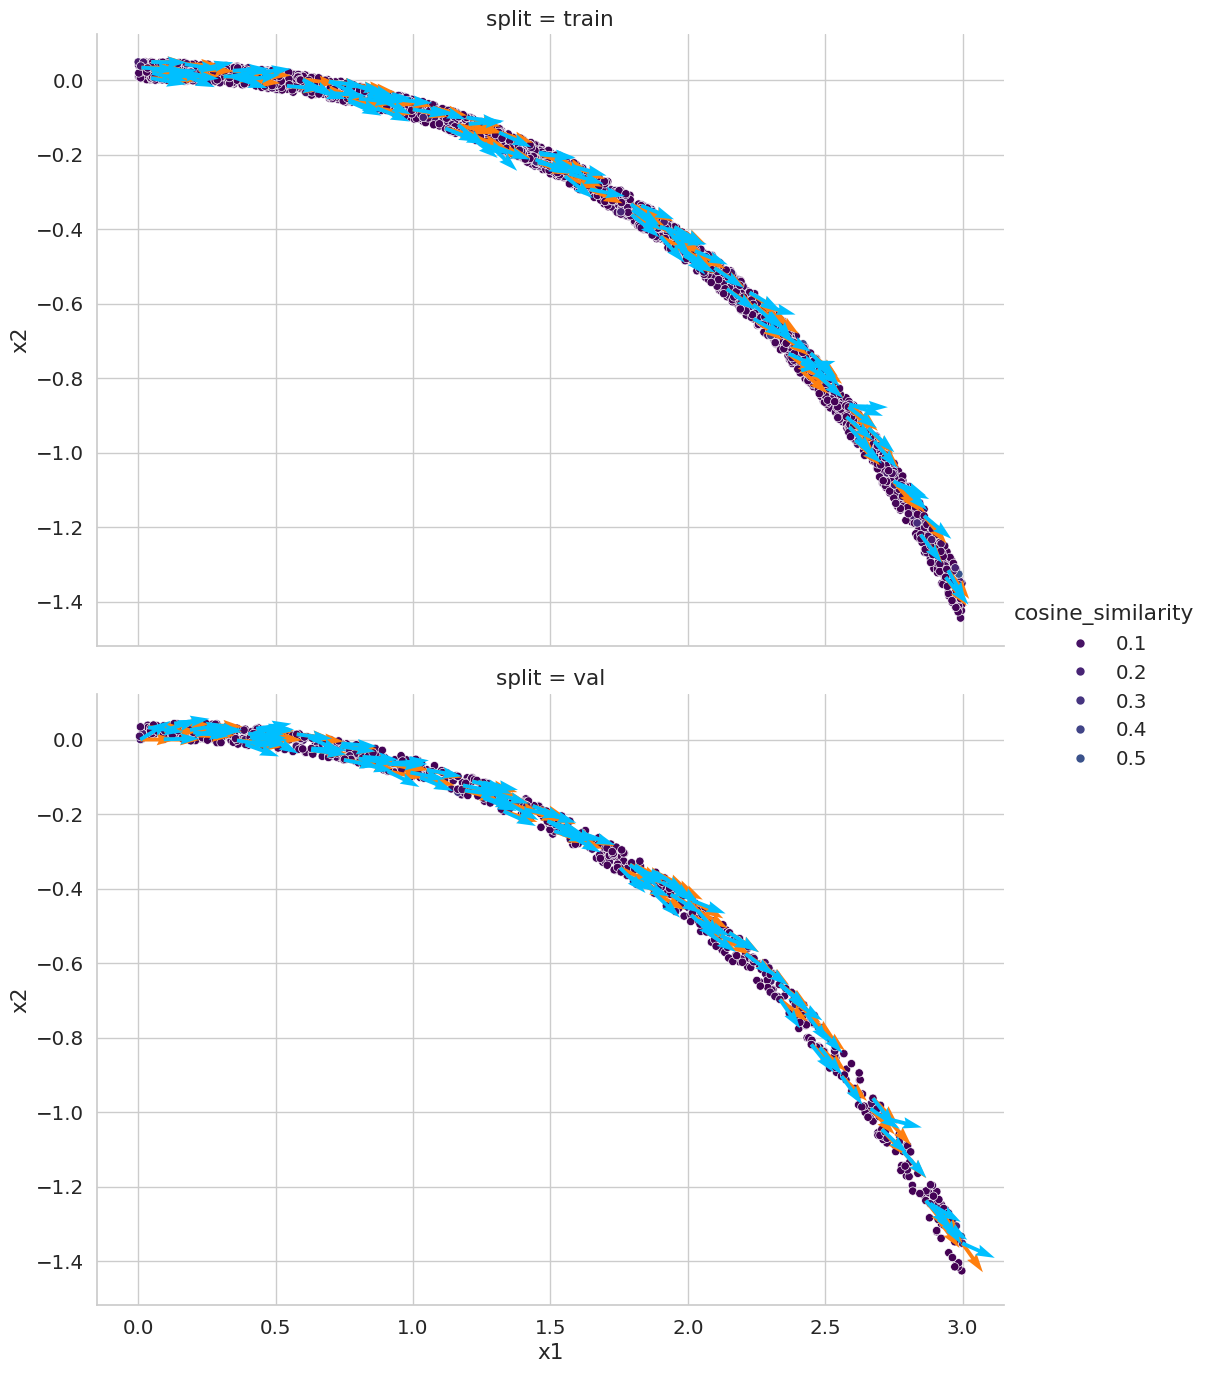

In [48]:
plot = (
    sns.relplot(
        kind='scatter',
        data=v['pred'].query('split != "test"'),
        row='split',
        hue='cosine_similarity',
        hue_norm=(0, 2),
        palette='viridis',
        x='x1', y='x2',
        height=7,
        aspect=1.5,
    )
)
for (row, col, hue), data in plot.facet_data():
    ax = plot.axes[row][col]
    data = data.sample(100)
    if False:
        x1, x2 = data['x1'], data['x2']
        v1, v2 = data['v1_pred'], data['v2_pred']
        color = None
    else:
        x1, x2 = data['x1'], data['x2']
        x1 = pd.concat([x1] * 2, ignore_index=True)
        x2 = pd.concat([x2] * 2, ignore_index=True)
        v1 = data[['v1', 'v1_pred']].melt(var_name='is_pred', value_name='v')
        v1, is_pred = v1['v'], (v1['is_pred'] == 'v1_pred').astype(float)
        v2 = data[['v2', 'v2_pred']].melt(var_name='is_pred', value_name='v')['v']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list('vel_pred', ['tab:orange', 'deepskyblue'])
        color = cmap(is_pred)
    ax.quiver(
        x1, x2, v1, v2,
        # headwidth=1, headlength=15, headaxislength=2,
        color=color,
    )

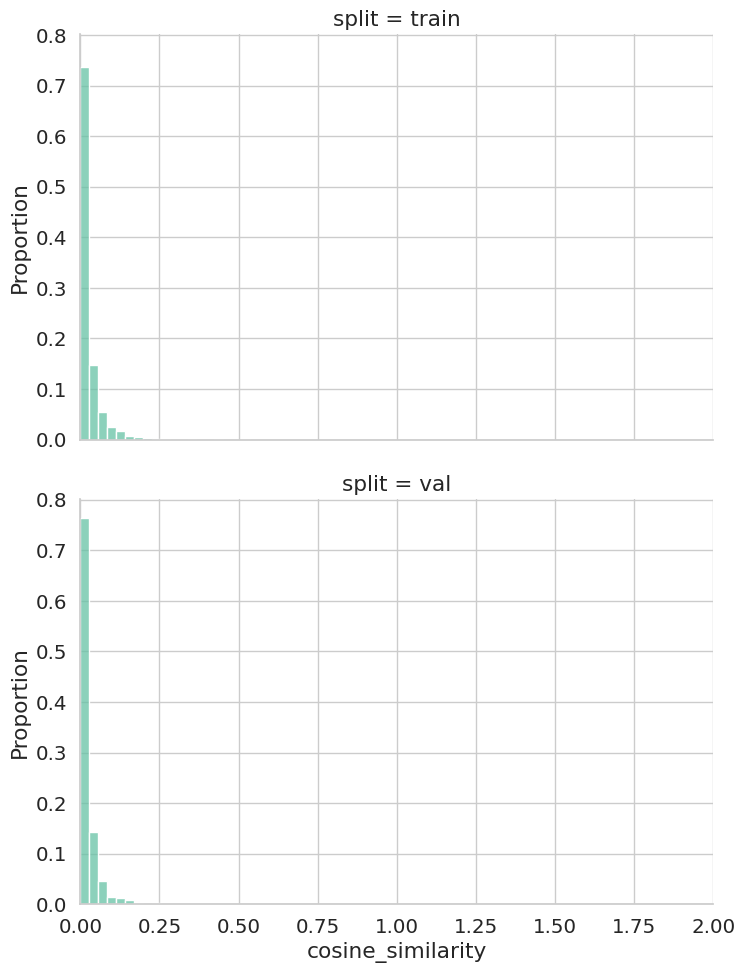

In [60]:
plot = (
    sns.displot(
        data=v['pred'].query('split != "test"'),
        stat='proportion',
        row='split',
        x='cosine_similarity',
        common_norm=False,
        height=5,
        aspect=1.5,
        bins=20,
    )
    .set(xlim=(0,2))
)